# Descriptive Analysis: GPR x Brent Oil Returns

**Purpose:** Visual exploration of the relationship between Brent returns
and all candidate regressors, at both daily and monthly frequency.
No regressions. Scatterplots, time series, distributions, rolling correlations.

| # | Section | Frequency |
|---|---------|-----------|
| 1 | Setup & data loading | — |
| 2 | Daily: GPRD x Brent | Daily |
| 3 | Monthly: GPR x Brent | Monthly |
| 4 | Monthly: Europe_Factor x Brent | Monthly |
| 5 | Daily: extended controls x Brent (VOIL, USD, natgas, stocks, REIA, supply, production) | Daily |
| 6 | Pairwise overview & correlation matrices | Both |


## 1. Setup & Data Loading

In [1]:
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns


os.chdir(r"C:\Users\Alejandro\Documents\MQuEA\TFM\main_code")
from auxi.data import import_data, update_brent

In [2]:
# Load the full merged daily panel from data.py
daily = import_data(freq="Daily")

# ── Derived columns ────────────────────────────────────────────────────────
# Diff-transforms for controls (were loaded separately in the old notebook)
daily["usd_index_d"]         = daily["usd_index"].diff()
daily["natgas_spotprice_d"]  = daily["natgas_spotprice"].diff()
daily["weekly_us_stocks_d"]  = daily["weekly_us_stocks"].diff()
daily["weekly_us_supply_d"]  = daily["weekly_us_supply"].diff()
daily["us_oil_production_d"] = daily["us_oil_production"].diff()
daily["REIA_ld"]             = np.log(daily["REIA"].replace(0, np.nan)).diff()

# VOIL lead columns (t+1 … t+5) — shift Brent_Return forward relative to VOIL_Return
voil_lead_cols = []
for i in range(1, 6):
    col = f"VOIL_Return (t+{i})"
    daily[col] = daily["VOIL_Return"].shift(-i)
    voil_lead_cols.append(col)

print(f"Daily panel: {daily.shape[0]:,} rows x {daily.shape[1]} cols  "
      f"({daily.index.min().date()} to {daily.index.max().date()})")

Daily panel: 13,269 rows x 67 cols  (1990-01-01 to 2026-04-30)


c:\Users\Alejandro\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [3]:
# Load the full merged monthly panel from data.py
monthly = import_data(freq="Monthly")

# EU and oil-producer country GPRC columns (still present from gpr.xlsx join)
eu_gprc  = [c for c in monthly.columns if c.startswith("GPRC_") and
            c[5:] in ["GBR","DEU","FRA","ITA","ESP","NLD","SWE","BEL","POL","GRC","NOR","UKR"]]
exp_gprc = [c for c in monthly.columns if c.startswith("GPRC_") and
            c[5:] in ["SAU","RUS","USA","IRQ","ARE","CAN","IRN","NGA","BRA"]]

print(f"Monthly panel:           {monthly.shape}")
print(f"EU GPRC columns:         {eu_gprc}")
print(f"Exporter GPRC columns:   {exp_gprc}")
print(f"Europe_Factor present:   {'Europe_Factor' in monthly.columns}")

Monthly panel:           (436, 161)
EU GPRC columns:         ['GPRC_BEL', 'GPRC_DEU', 'GPRC_ESP', 'GPRC_FRA', 'GPRC_GBR', 'GPRC_ITA', 'GPRC_NLD', 'GPRC_NOR', 'GPRC_POL', 'GPRC_SWE', 'GPRC_UKR']
Exporter GPRC columns:   ['GPRC_BRA', 'GPRC_CAN', 'GPRC_RUS', 'GPRC_SAU', 'GPRC_USA']
Europe_Factor present:   True



## Daily: GPRD x Brent Returns


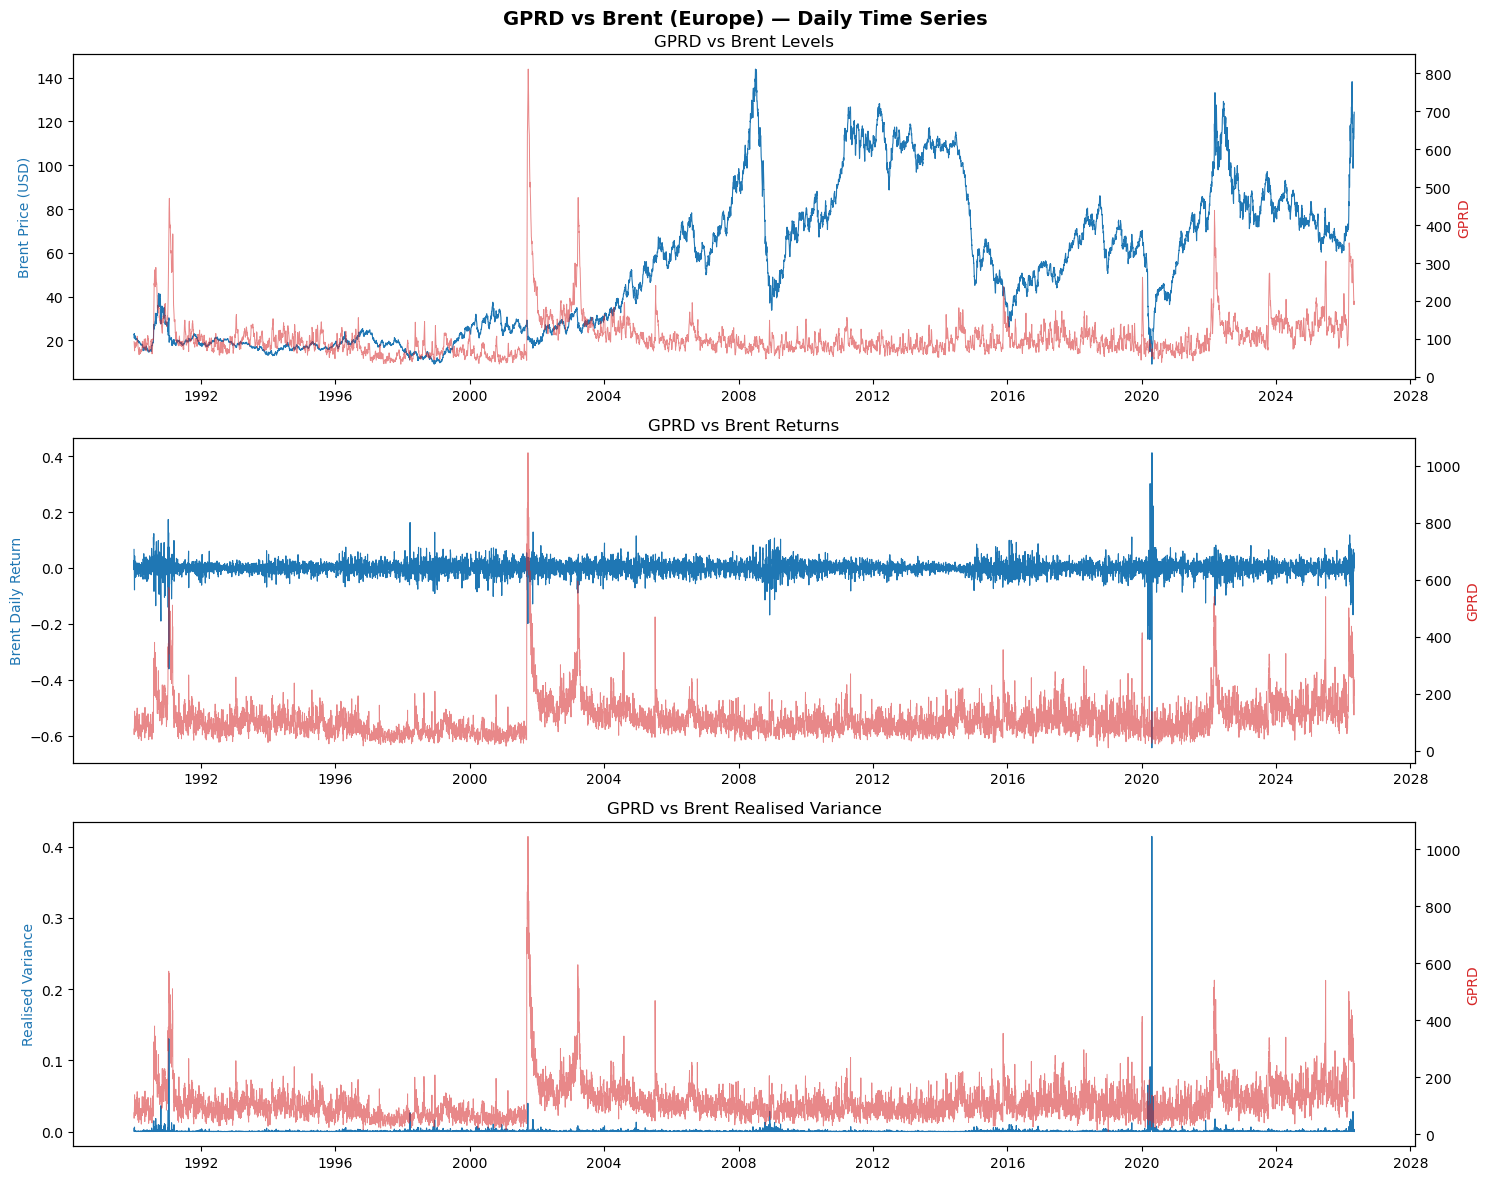

In [4]:
pairs = [
    ("GPRD_MA7", "Brent_Price",          "Brent Price (USD)",  "Levels"),
    ("GPRD", "Brent_Return",         "Brent Daily Return", "Returns"),
    ("GPRD", "Realized_Volatility",  "Realised Variance",  "Realised Variance"),

]

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=False)
for ax, (x, y, ylabel, subtitle) in zip(axes, pairs):
    sub = daily[[x, y]].dropna()
    # sub = sub["02-28-2022":"06-01-2022"]                                                            # Time constraint, to make zoom on the cart
    ax.plot(sub.index, sub[y], color="tab:blue", lw=0.8)
    ax.set_ylabel(ylabel, color="tab:blue")
    ax2 = ax.twinx()
    ax2.plot(sub.index, sub[x], color="tab:red", alpha=0.55, lw=0.7)
    ax2.set_ylabel("GPRD", color="tab:red")
    ax.set_title(f"GPRD vs Brent {subtitle}")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle("GPRD vs Brent (Europe) — Daily Time Series", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

In oder to check which window for the GPR moving average fits best the Brent data, we will run multiple out-of-sample forecast and keep the one that minimizes the RMSE.

In [5]:
from auxi.descriptive import optimize_gprd_window

c:\Users\Alejandro\Documents\MQuEA\TFM\main_code\auxi\descriptive.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_work[col_name] = df_work["GPRD"].rolling(window=w).mean()
c:\Users\Alejandro\Documents\MQuEA\TFM\main_code\auxi\descriptive.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_work[col_name] = df_work["GPRD"].rolling(window=w).mean()
c:\Users\Alejandro\Documents\MQuEA\TFM\main_code\auxi\descriptive.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.ins

Optimization setup: 2192 Train days, 548 Test days.
Optimal Window (Pinball Loss): 86 days
Optimal Window (RMSE): 5 days


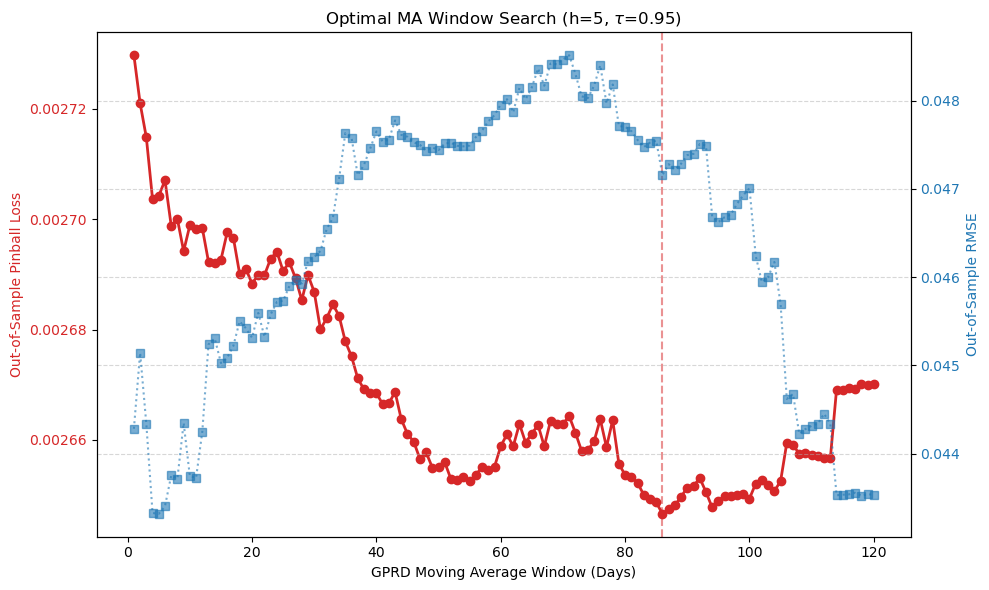

In [7]:
import seaborn as sns

# Run the optimization for the 95th percentile, predicting 5 days ahead
opt_results = optimize_gprd_window(
    df=daily, 
    y="Brent_Return", 
    tau=0.95, 
    h=30, 
    max_window=120, 
    controls=["usd_index_ld","Brent_Abs_Return (t-1)", "Realized_Volatility_MA2", "REIA_fd" ,"natgas_spotprice_ld", "weekly_us_stocks_ld"]  

)

# Find the absolute optimal windows
best_pinball_window = opt_results.loc[opt_results['Pinball_Loss'].idxmin(), 'Window']
best_rmse_window = opt_results.loc[opt_results['RMSE'].idxmin(), 'Window']

print(f"Optimal Window (Pinball Loss): {int(best_pinball_window)} days")
print(f"Optimal Window (RMSE): {int(best_rmse_window)} days")

# Plotting the Loss Curve
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(opt_results["Window"], opt_results["Pinball_Loss"], color="tab:red", marker="o", linewidth=2, label="Pinball Loss (Target)")
ax1.axvline(best_pinball_window, color="tab:red", linestyle="--", alpha=0.5)
ax1.set_xlabel("GPRD Moving Average Window (Days)")
ax1.set_ylabel("Out-of-Sample Pinball Loss", color="tab:red")
ax1.tick_params(axis='y', labelcolor="tab:red")

# Create a twin axis for RMSE
ax2 = ax1.twinx()
ax2.plot(opt_results["Window"], opt_results["RMSE"], color="tab:blue", marker="s", linestyle=":", alpha=0.6, label="RMSE")
ax2.set_ylabel("Out-of-Sample RMSE", color="tab:blue")
ax2.tick_params(axis='y', labelcolor="tab:blue")

plt.title(f"Optimal MA Window Search (h=5, $\\tau$=0.95)")
fig.tight_layout()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### 2.2 Scatter — GPRD vs each Brent outcome

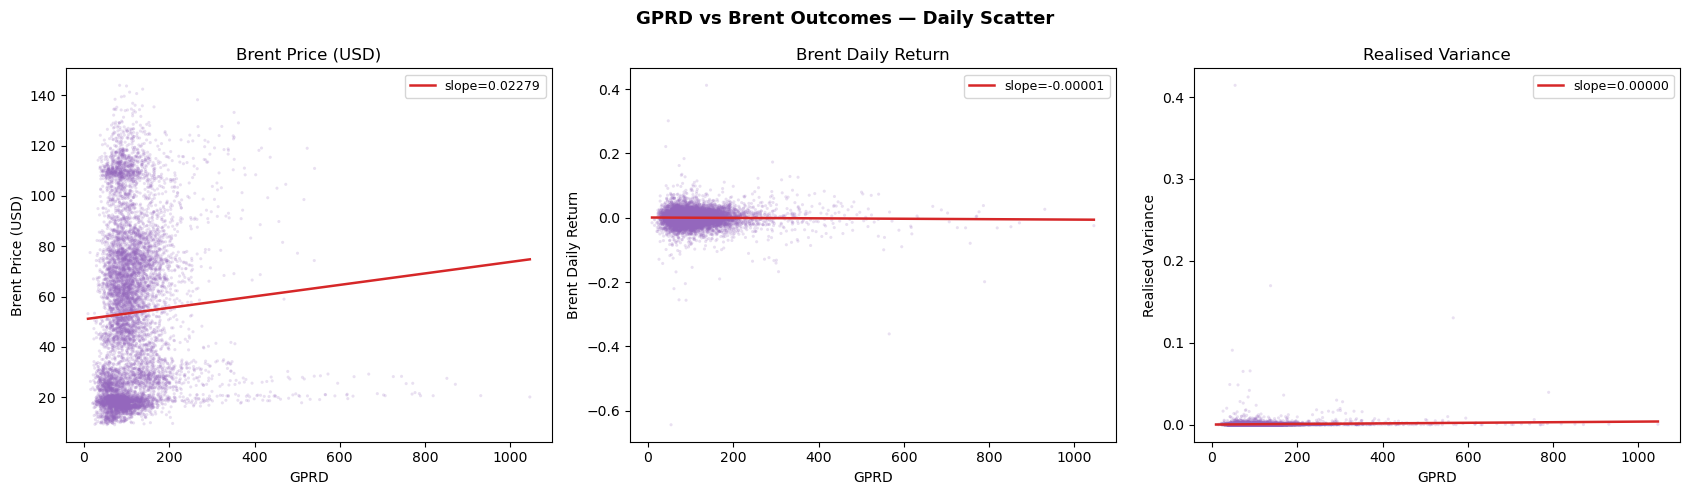

In [8]:
y_vars = [
    ("Brent_Price",         "Brent Price (USD)"),
    ("Brent_Return",        "Brent Daily Return"),
    ("Realized_Volatility", "Realised Variance"),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("GPRD vs Brent Outcomes — Daily Scatter", fontsize=13, fontweight="bold")

for ax, (y, ylabel) in zip(axes, y_vars):
    sub = daily[["GPRD", y]].dropna()
    ax.scatter(sub["GPRD"], sub[y], alpha=0.2, s=5, color="tab:purple", edgecolors="none")
    m, b = np.polyfit(sub["GPRD"], sub[y], 1)
    xl = np.linspace(sub["GPRD"].min(), sub["GPRD"].max(), 200)
    ax.plot(xl, m * xl + b, color="tab:red", lw=1.8, label=f"slope={m:.5f}")
    ax.set_xlabel("GPRD"); ax.set_ylabel(ylabel); ax.set_title(ylabel); ax.legend(fontsize=9)

plt.tight_layout(); plt.show()

### 2.3 Signed vs absolute return

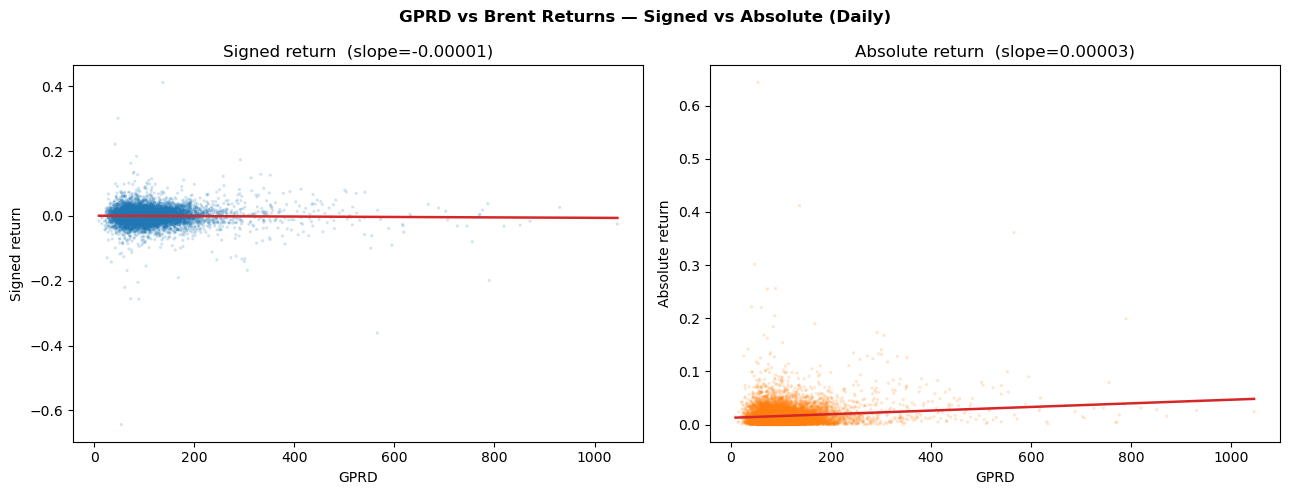

In [9]:
sub = daily[["GPRD", "Brent_Return"]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("GPRD vs Brent Returns — Signed vs Absolute (Daily)", fontweight="bold")

for ax, (series, color, label) in zip(axes, [
    (sub["Brent_Return"],       "tab:blue",   "Signed return"),
    (sub["Brent_Return"].abs(), "tab:orange", "Absolute return"),
]):
    ax.scatter(sub["GPRD"], series, alpha=0.2, s=5, color=color, edgecolors="none")
    m, b = np.polyfit(sub["GPRD"], series, 1)
    xl = np.linspace(sub["GPRD"].min(), sub["GPRD"].max(), 200)
    ax.plot(xl, m * xl + b, color="tab:red", lw=1.8)
    ax.set_xlabel("GPRD"); ax.set_ylabel(label); ax.set_title(f"{label}  (slope={m:.5f})")

plt.tight_layout(); plt.show()

### 2.4 Distribution of Brent returns by GPRD tercile

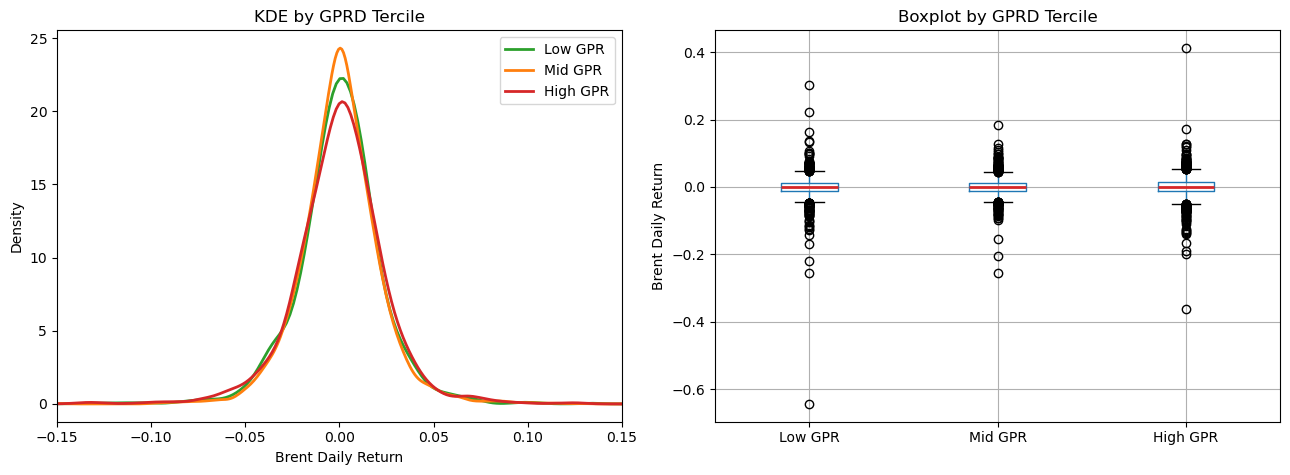

               count     mean      std      min      25%      50%      75%  \
GPRD_tercile                                                                 
Low GPR       2999.0 -0.00001  0.02730 -0.64370 -0.01118  0.00070  0.01200   
Mid GPR       2997.0  0.00027  0.02228 -0.25639 -0.01085  0.00009  0.01166   
High GPR      2999.0  0.00013  0.02707 -0.36121 -0.01244  0.00081  0.01342   

                  max  
GPRD_tercile           
Low GPR       0.30161  
Mid GPR       0.18405  
High GPR      0.41202  


C:\Users\Alejandro\AppData\Local\Temp\ipykernel_1760\2509356356.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(sub.groupby("GPRD_tercile")["Brent_Return"].describe().round(5))


In [10]:
sub = daily[["GPRD", "Brent_Return"]].dropna().copy()
sub["GPRD_tercile"] = pd.qcut(sub["GPRD"], q=3, labels=["Low GPR", "Mid GPR", "High GPR"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Brent Return Distribution by GPRD Tercile (Daily)", fontweight="bold")

for grp, color in zip(["Low GPR", "Mid GPR", "High GPR"],
                       ["tab:green", "tab:orange", "tab:red"]):
    sub[sub["GPRD_tercile"] == grp]["Brent_Return"].plot.kde(
        ax=axes[0], label=grp, color=color, lw=2)
axes[0].set_xlabel("Brent Daily Return"); axes[0].set_title("KDE by GPRD Tercile")
axes[0].legend(); axes[0].set_xlim(-0.15, 0.15)

sub.boxplot(column="Brent_Return", by="GPRD_tercile", ax=axes[1],
            medianprops=dict(color="tab:red", lw=2))
axes[1].set_title("Boxplot by GPRD Tercile")
axes[1].set_xlabel(""); axes[1].set_ylabel("Brent Daily Return"); plt.suptitle("")
plt.tight_layout(); plt.show()

print(sub.groupby("GPRD_tercile")["Brent_Return"].describe().round(5))

### 2.5 Rolling 250-day correlation: GPRD x Brent Returns

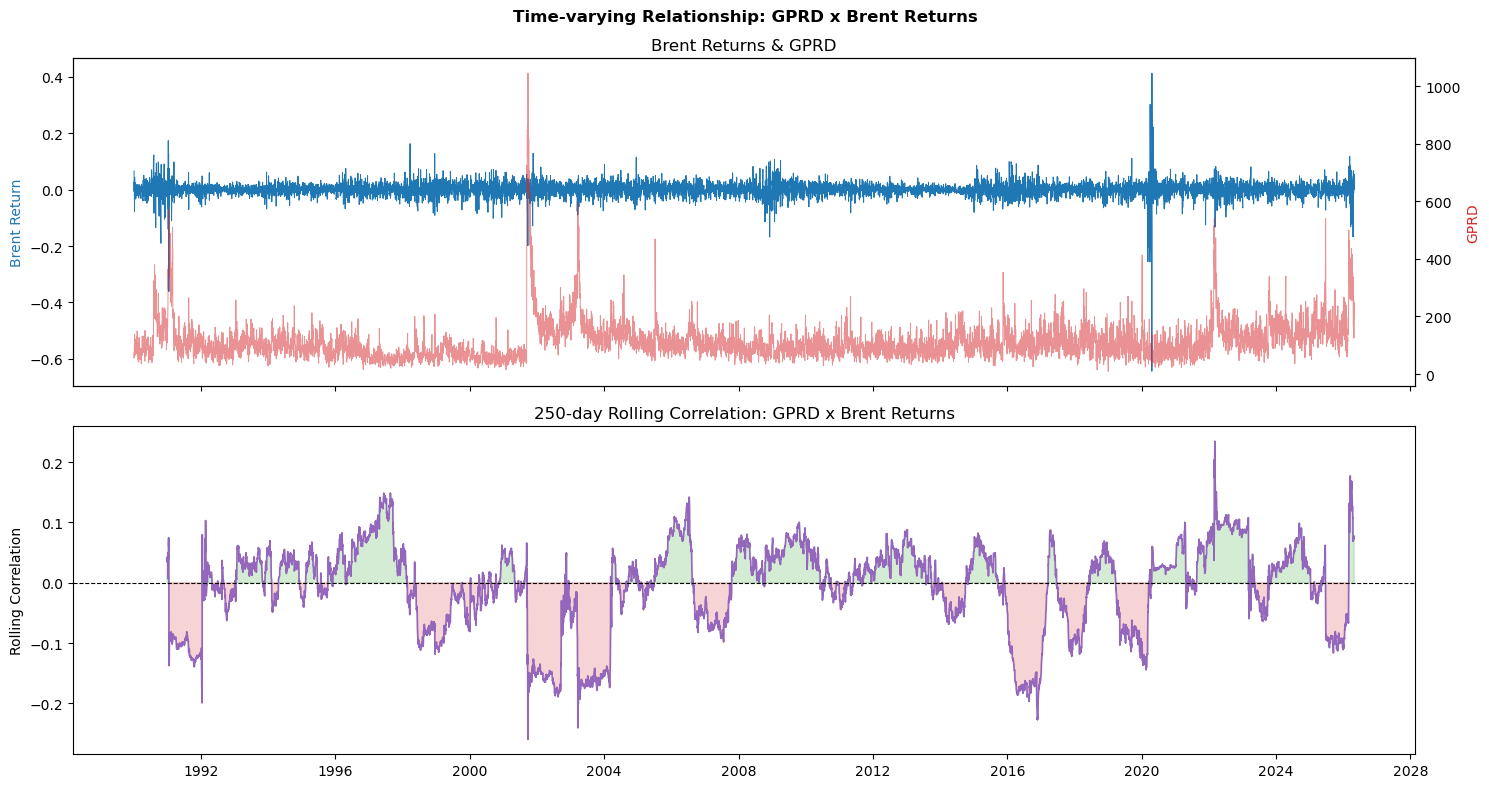

In [11]:
sub = daily[["GPRD", "Brent_Return"]].dropna()
roll_corr = sub["GPRD"].rolling(250).corr(sub["Brent_Return"])

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].plot(sub.index, sub["Brent_Return"], color="tab:blue", lw=0.7)
ax_r = axes[0].twinx()
ax_r.plot(sub.index, sub["GPRD"], color="tab:red", alpha=0.5, lw=0.7)
axes[0].set_ylabel("Brent Return", color="tab:blue")
ax_r.set_ylabel("GPRD", color="tab:red")
axes[0].set_title("Brent Returns & GPRD")

axes[1].plot(roll_corr.index, roll_corr, color="tab:purple", lw=1.2)
axes[1].axhline(0, color="black", lw=0.8, ls="--")
axes[1].fill_between(roll_corr.index, roll_corr, 0,
                     where=roll_corr >= 0, alpha=0.2, color="tab:green")
axes[1].fill_between(roll_corr.index, roll_corr, 0,
                     where=roll_corr < 0, alpha=0.2, color="tab:red")
axes[1].set_ylabel("Rolling Correlation")
axes[1].set_title("250-day Rolling Correlation: GPRD x Brent Returns")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle("Time-varying Relationship: GPRD x Brent Returns", fontweight="bold")
plt.tight_layout(); plt.show()

---
## 3. Monthly: GPR x Brent Returns


### 3.1 Time series — GPR vs Brent (levels and returns)

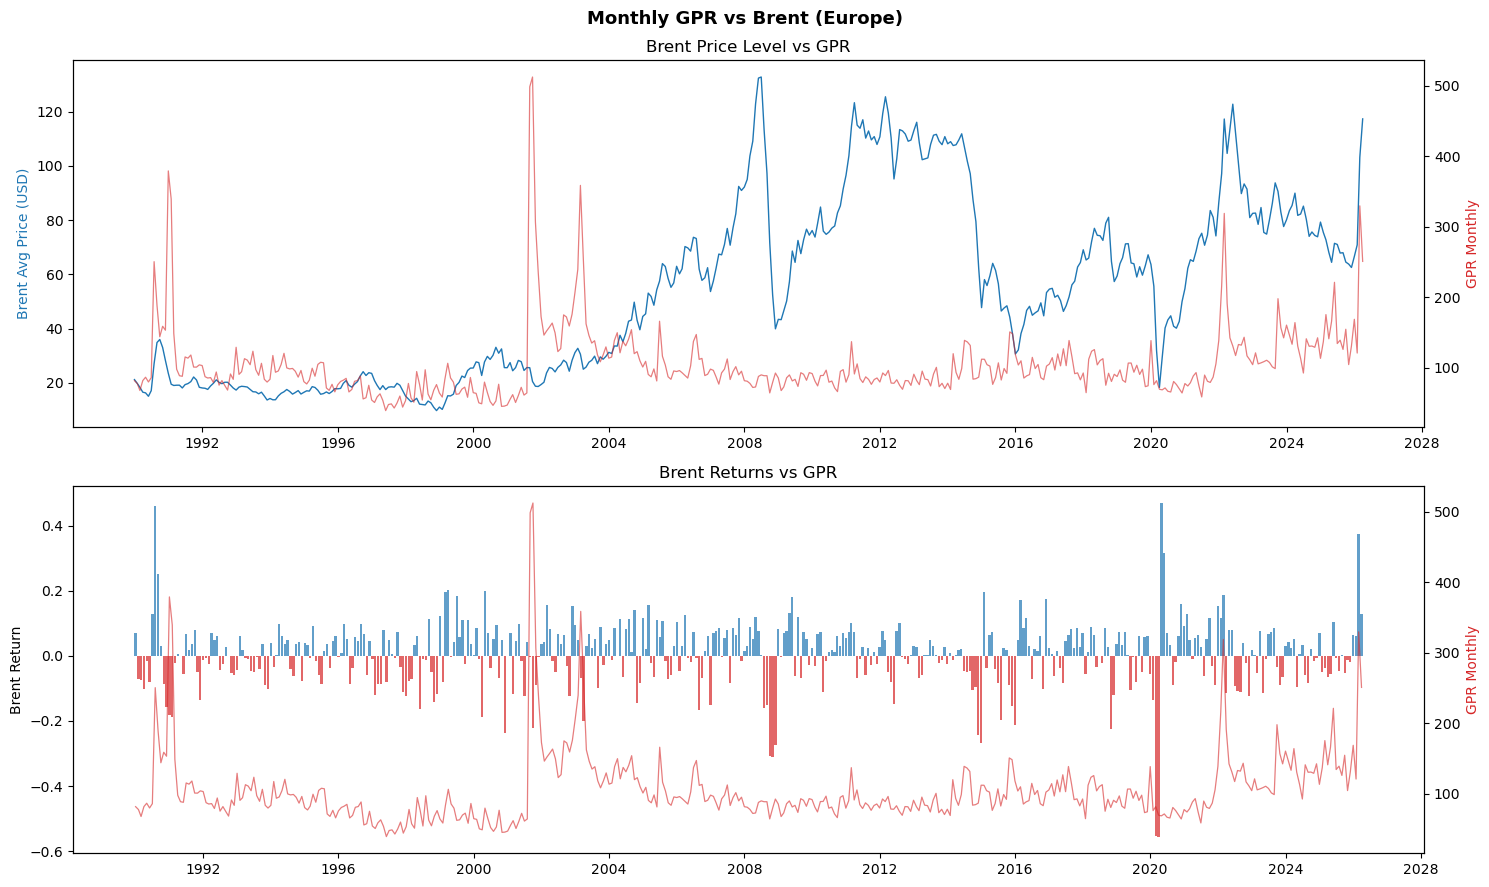

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=False)
fig.suptitle("Monthly GPR vs Brent (Europe)", fontsize=13, fontweight="bold")

# Price level
sub_l = monthly[["GPR", "Brent_Price"]].dropna()
axes[0].plot(sub_l.index, sub_l["Brent_Price"], color="tab:blue", lw=1.0)
axes[0].set_ylabel("Brent Avg Price (USD)", color="tab:blue")
ax2 = axes[0].twinx()
ax2.plot(sub_l.index, sub_l["GPR"], color="tab:red", alpha=0.6, lw=0.9)
ax2.set_ylabel("GPR Monthly", color="tab:red")
axes[0].set_title("Brent Price Level vs GPR")

# Returns
sub_r = monthly[["GPR", "Brent_Return"]].dropna()
axes[1].bar(sub_r.index, sub_r["Brent_Return"],
            color=["tab:red" if v < 0 else "tab:blue" for v in sub_r["Brent_Return"]],
            width=25, alpha=0.7)
ax3 = axes[1].twinx()
ax3.plot(sub_r.index, sub_r["GPR"], color="tab:red", alpha=0.6, lw=0.9)
ax3.set_ylabel("GPR Monthly", color="tab:red")
axes[1].set_ylabel("Brent Return"); axes[1].set_title("Brent Returns vs GPR")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout(); plt.show()

### 3.2 Scatter — GPR vs Brent returns: signed and absolute, contemporaneous and forward

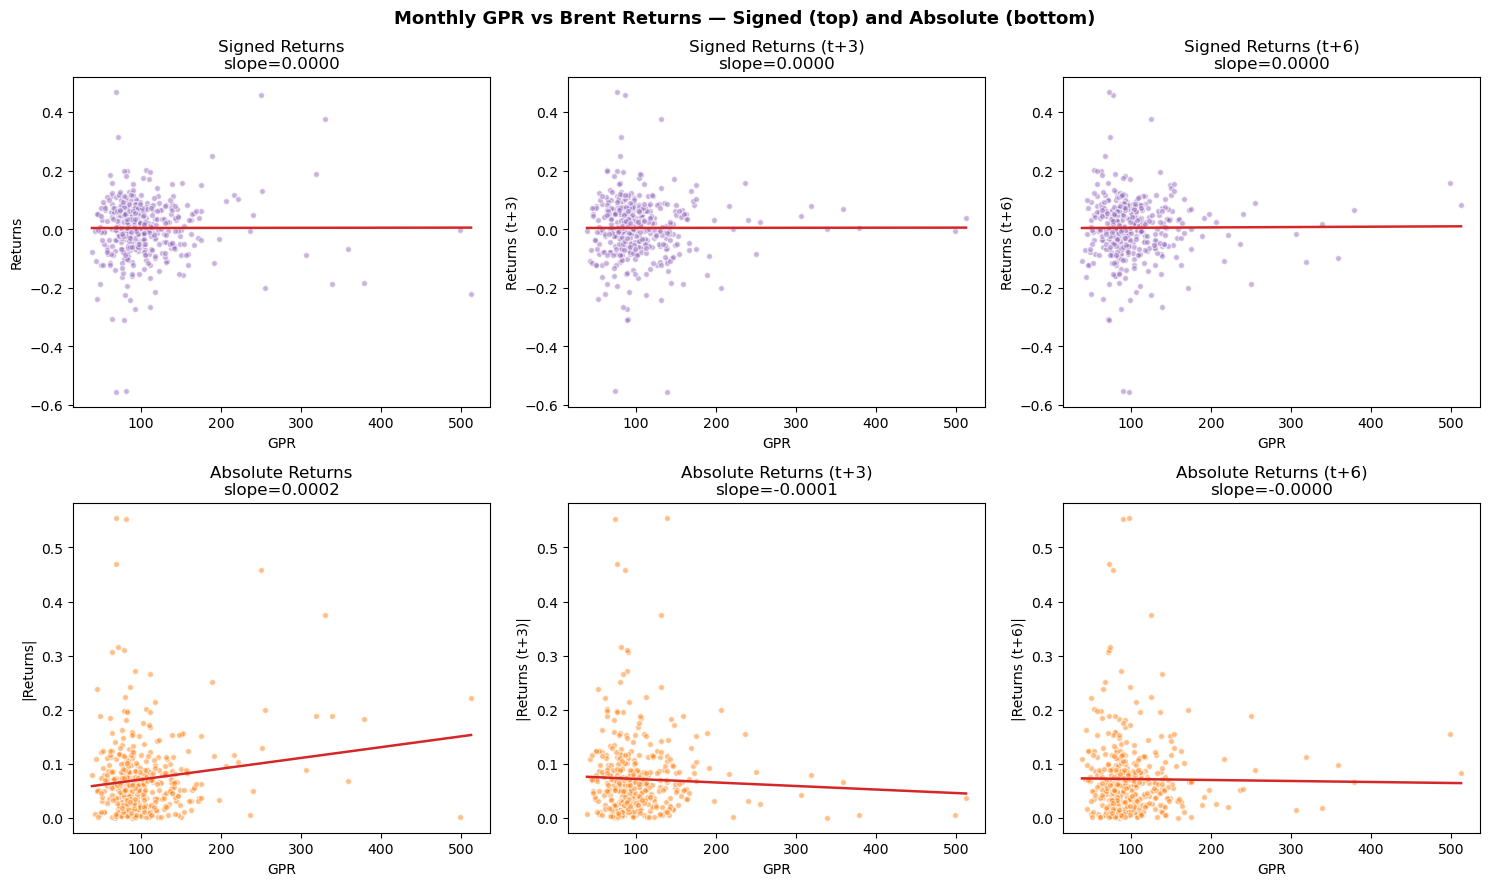

In [13]:
# Forward-return columns come from the lagged columns stored in brent.xlsx
# (Brent_Return (t-i) are lags; forward views require shifting at analysis time)
fwd_cols = []
for i in [3, 6]:
    col = f"Brent_Return (t+{i})"
    monthly[col] = monthly["Brent_Return"].shift(-i)
    fwd_cols.append(col)

y_cols_m = ["Brent_Return"] + [c for c in fwd_cols if c in monthly.columns]

fig, axes = plt.subplots(2, len(y_cols_m), figsize=(5 * len(y_cols_m), 9))
fig.suptitle("Monthly GPR vs Brent Returns — Signed (top) and Absolute (bottom)",
             fontsize=13, fontweight="bold")

for col_idx, y in enumerate(y_cols_m):
    sub = monthly[["GPR", y]].dropna()
    label = y.replace("Brent_Return", "Returns").strip()
    xl = np.linspace(sub["GPR"].min(), sub["GPR"].max(), 200)

    for row_idx, (series, color, tag) in enumerate([
        (sub[y],       "tab:purple", "Signed"),
        (sub[y].abs(), "tab:orange", "Absolute"),
    ]):
        ax = axes[row_idx, col_idx]
        ax.scatter(sub["GPR"], series, alpha=0.5, s=18, color=color, edgecolors="w")
        m, b = np.polyfit(sub["GPR"], series, 1)
        ax.plot(xl, m * xl + b, color="tab:red", lw=1.8)
        ax.set_xlabel("GPR")
        ax.set_ylabel(f"{'|' if tag=='Absolute' else ''}{label}{'|' if tag=='Absolute' else ''}")
        ax.set_title(f"{tag} {label}\nslope={m:.4f}")

plt.tight_layout(); plt.show()

### 3.3 GPR vs Brent realised volatility

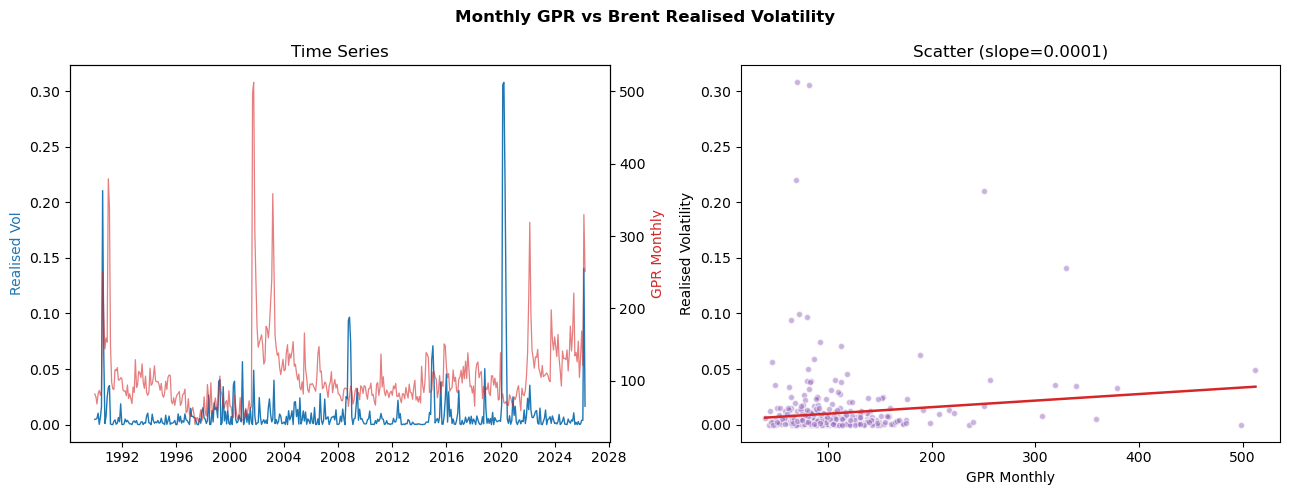

In [14]:
sub_v = monthly[["GPR", "Realized_Volatility"]].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Monthly GPR vs Brent Realised Volatility", fontweight="bold")

axes[0].plot(sub_v.index, sub_v["Realized_Volatility"], color="tab:blue", lw=1.0)
axes[0].set_ylabel("Realised Vol", color="tab:blue")
ax2 = axes[0].twinx()
ax2.plot(sub_v.index, sub_v["GPR"], color="tab:red", alpha=0.6, lw=0.9)
ax2.set_ylabel("GPR Monthly", color="tab:red")
axes[0].set_title("Time Series")

axes[1].scatter(sub_v["GPR"], sub_v["Realized_Volatility"], alpha=0.5, s=20,
                color="tab:purple", edgecolors="w")
m, b = np.polyfit(sub_v["GPR"], sub_v["Realized_Volatility"], 1)
xl = np.linspace(sub_v["GPR"].min(), sub_v["GPR"].max(), 200)
axes[1].plot(xl, m * xl + b, color="tab:red", lw=1.8)
axes[1].set_xlabel("GPR Monthly"); axes[1].set_ylabel("Realised Volatility")
axes[1].set_title(f"Scatter (slope={m:.4f})")
plt.tight_layout(); plt.show()

### 3.4 Distribution of Brent returns by GPR tercile

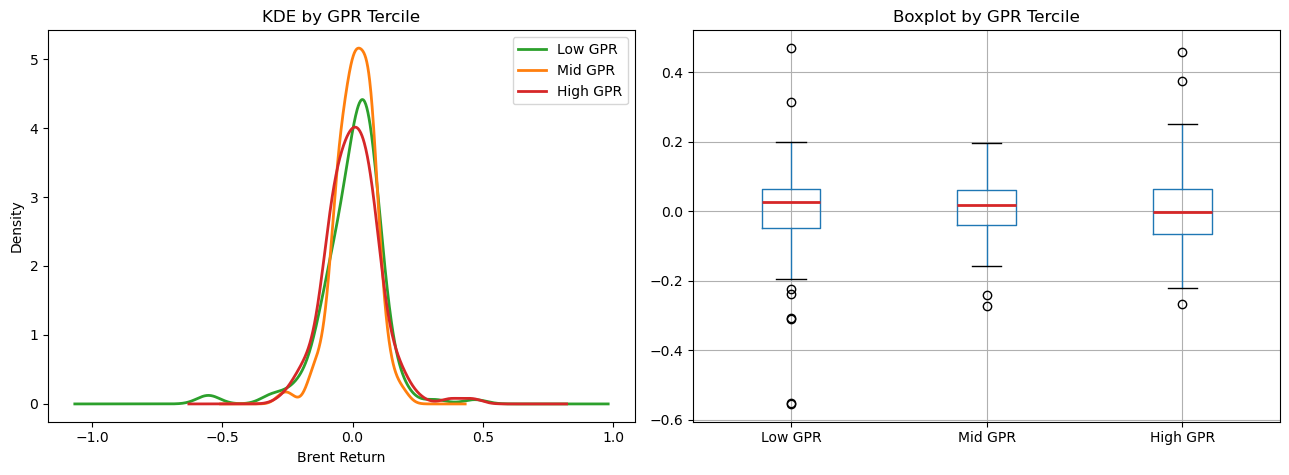

             count     mean      std      min      25%      50%      75%  \
GPR_tercile                                                                
Low GPR      146.0  0.00124  0.11961 -0.55491 -0.04808  0.02594  0.06439   
Mid GPR      145.0  0.00800  0.07398 -0.27236 -0.04099  0.01635  0.06189   
High GPR     145.0  0.00301  0.10309 -0.26635 -0.06531 -0.00129  0.06442   

                 max  
GPR_tercile           
Low GPR      0.46910  
Mid GPR      0.19725  
High GPR     0.45891  


C:\Users\Alejandro\AppData\Local\Temp\ipykernel_1760\1027118175.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(sub.groupby("GPR_tercile")["Brent_Return"].describe().round(5))


In [15]:
sub = monthly[["GPR", "Brent_Return"]].dropna().copy()
sub["GPR_tercile"] = pd.qcut(sub["GPR"], q=3, labels=["Low GPR", "Mid GPR", "High GPR"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Monthly Brent Return Distribution by GPR Tercile", fontweight="bold")

for grp, color in zip(["Low GPR", "Mid GPR", "High GPR"],
                       ["tab:green", "tab:orange", "tab:red"]):
    sub[sub["GPR_tercile"] == grp]["Brent_Return"].plot.kde(
        ax=axes[0], label=grp, color=color, lw=2)
axes[0].set_xlabel("Brent Return"); axes[0].set_title("KDE by GPR Tercile"); axes[0].legend()

sub.boxplot(column="Brent_Return", by="GPR_tercile", ax=axes[1],
            medianprops=dict(color="tab:red", lw=2))
axes[1].set_title("Boxplot by GPR Tercile"); axes[1].set_xlabel(""); plt.suptitle("")
plt.tight_layout(); plt.show()

print(sub.groupby("GPR_tercile")["Brent_Return"].describe().round(5))

### 3.5 Rolling 24-month correlation: GPR x Brent Returns

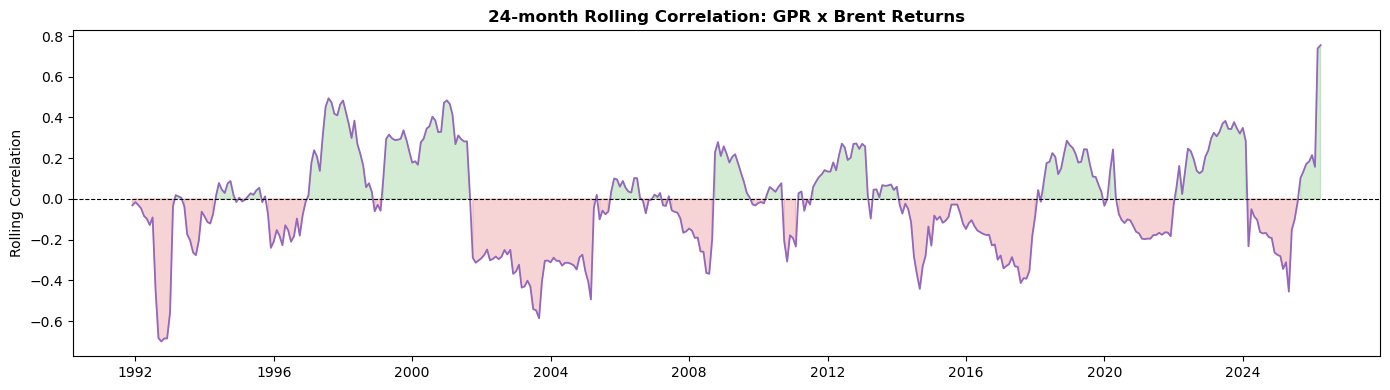

In [17]:
sub = monthly[["GPR", "Brent_Return"]].dropna()
roll_m = sub["GPR"].rolling(24).corr(sub["Brent_Return"])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(roll_m.index, roll_m, color="tab:purple", lw=1.3)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.fill_between(roll_m.index, roll_m, 0, where=roll_m >= 0, alpha=0.2, color="tab:green")
ax.fill_between(roll_m.index, roll_m, 0, where=roll_m <  0, alpha=0.2, color="tab:red")
ax.set_ylabel("Rolling Correlation")
ax.set_title("24-month Rolling Correlation: GPR x Brent Returns", fontweight="bold")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout(); plt.show()

### 3.6 European country GPRC — scatter grid vs Brent returns

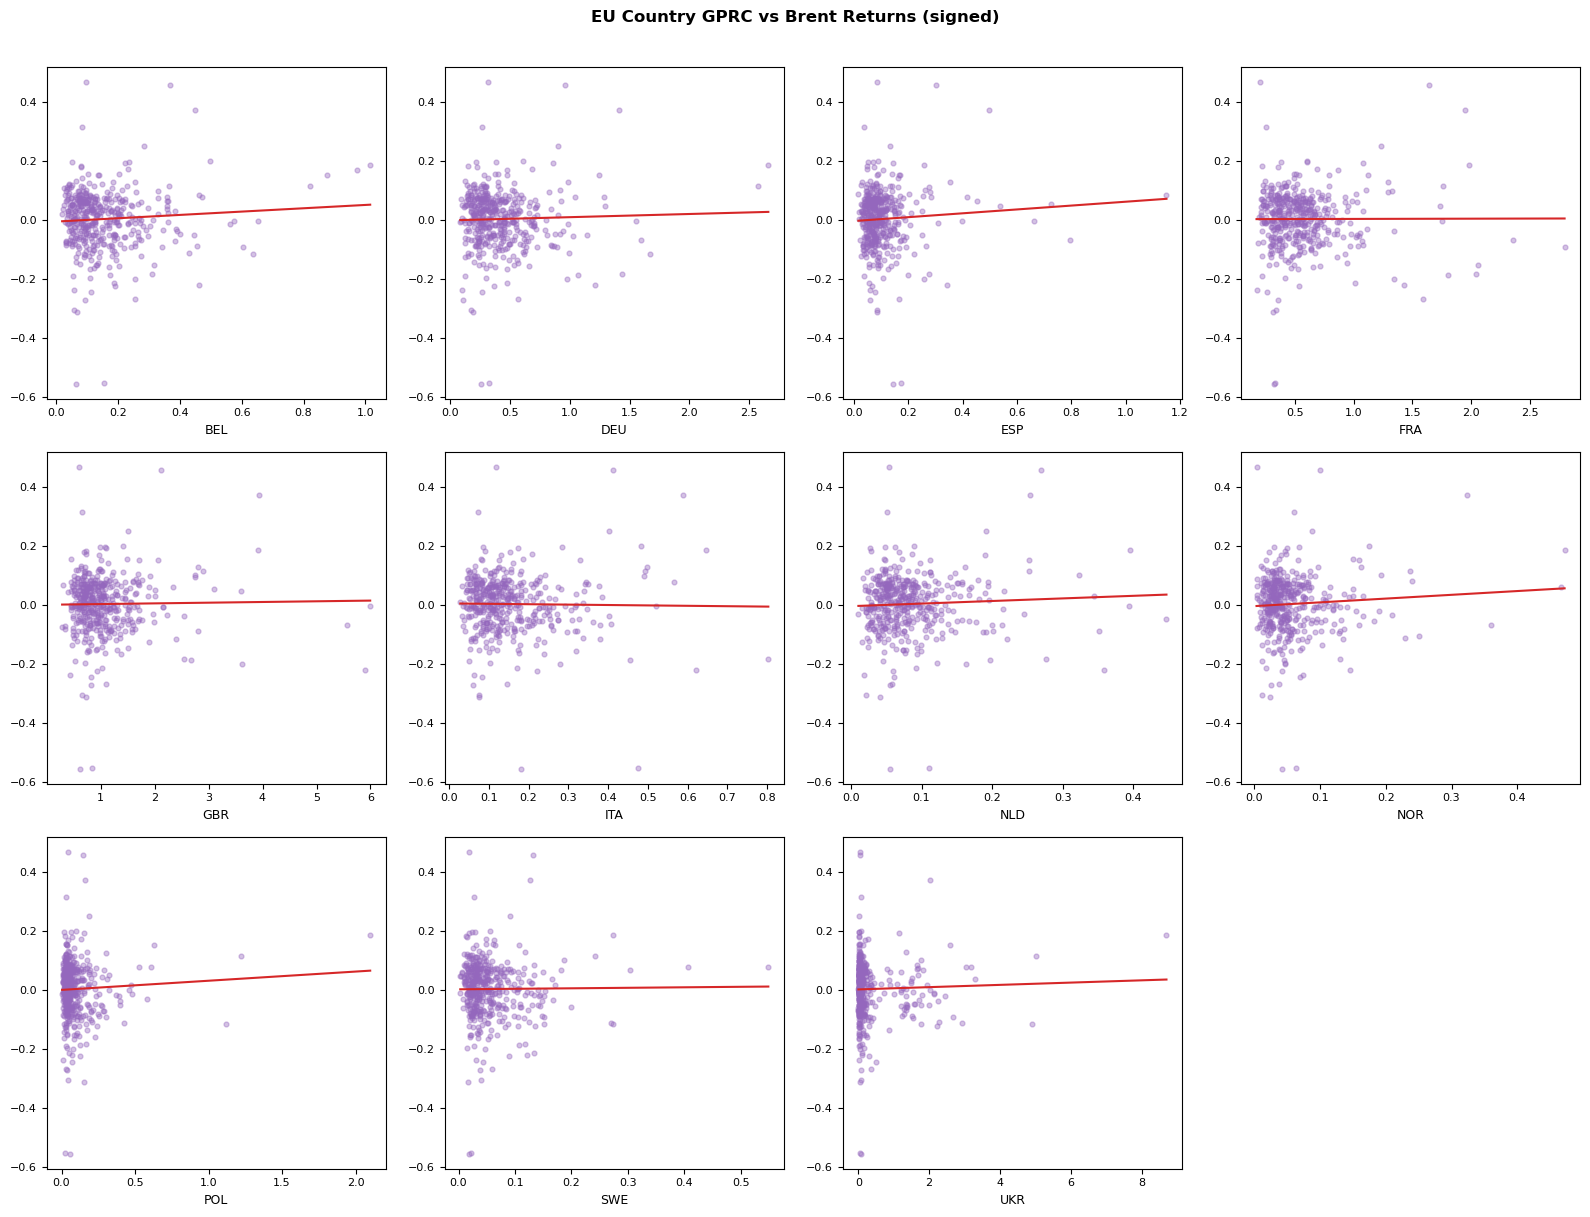

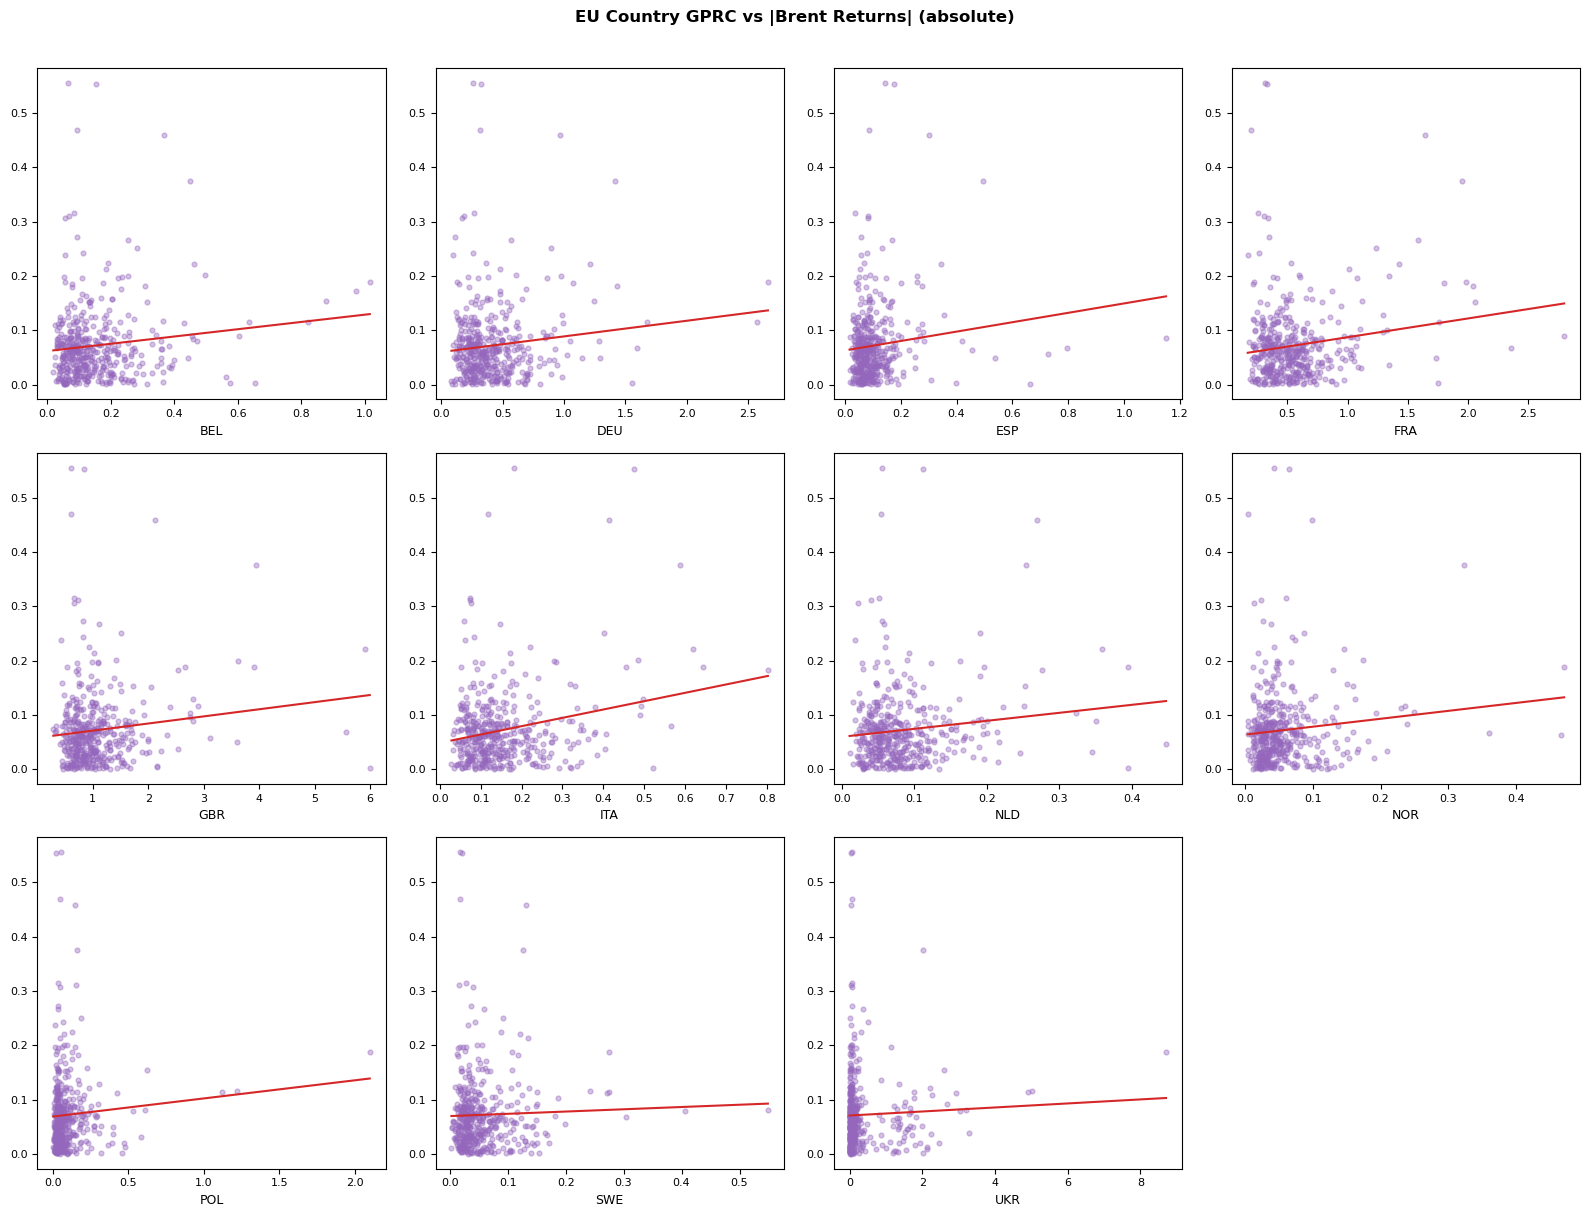

In [18]:
def scatter_grid(df, x_cols, y_col, title, abs_y=False, ncols=4):
    df = df.copy()
    plot_y = y_col + "_abs" if abs_y else y_col
    df[plot_y] = df[y_col].abs() if abs_y else df[y_col]
    x_cols = [c for c in x_cols if c in df.columns]
    nrows = max(1, (len(x_cols) + ncols - 1) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.array(axes).flatten()
    for i, xc in enumerate(x_cols):
        sub = df[[xc, plot_y]].dropna()
        axes[i].scatter(sub[xc], sub[plot_y], alpha=0.4, s=12, color="tab:purple")
        if len(sub) > 2:
            m, b = np.polyfit(sub[xc], sub[plot_y], 1)
            xl = np.linspace(sub[xc].min(), sub[xc].max(), 100)
            axes[i].plot(xl, m * xl + b, color="tab:red", lw=1.5)
        axes[i].set_xlabel(xc.replace("GPRC_", ""), fontsize=9)
        axes[i].tick_params(labelsize=8)
    for j in range(len(x_cols), len(axes)):
        fig.delaxes(axes[j])
    fig.suptitle(title, fontsize=12, fontweight="bold", y=1.01)
    plt.tight_layout(); plt.show()

scatter_grid(monthly, eu_gprc, "Brent_Return",
             "EU Country GPRC vs Brent Returns (signed)")
scatter_grid(monthly, eu_gprc, "Brent_Return",
             "EU Country GPRC vs |Brent Returns| (absolute)", abs_y=True)

### 3.7 Oil-producer country GPRC — scatter grid vs Brent returns

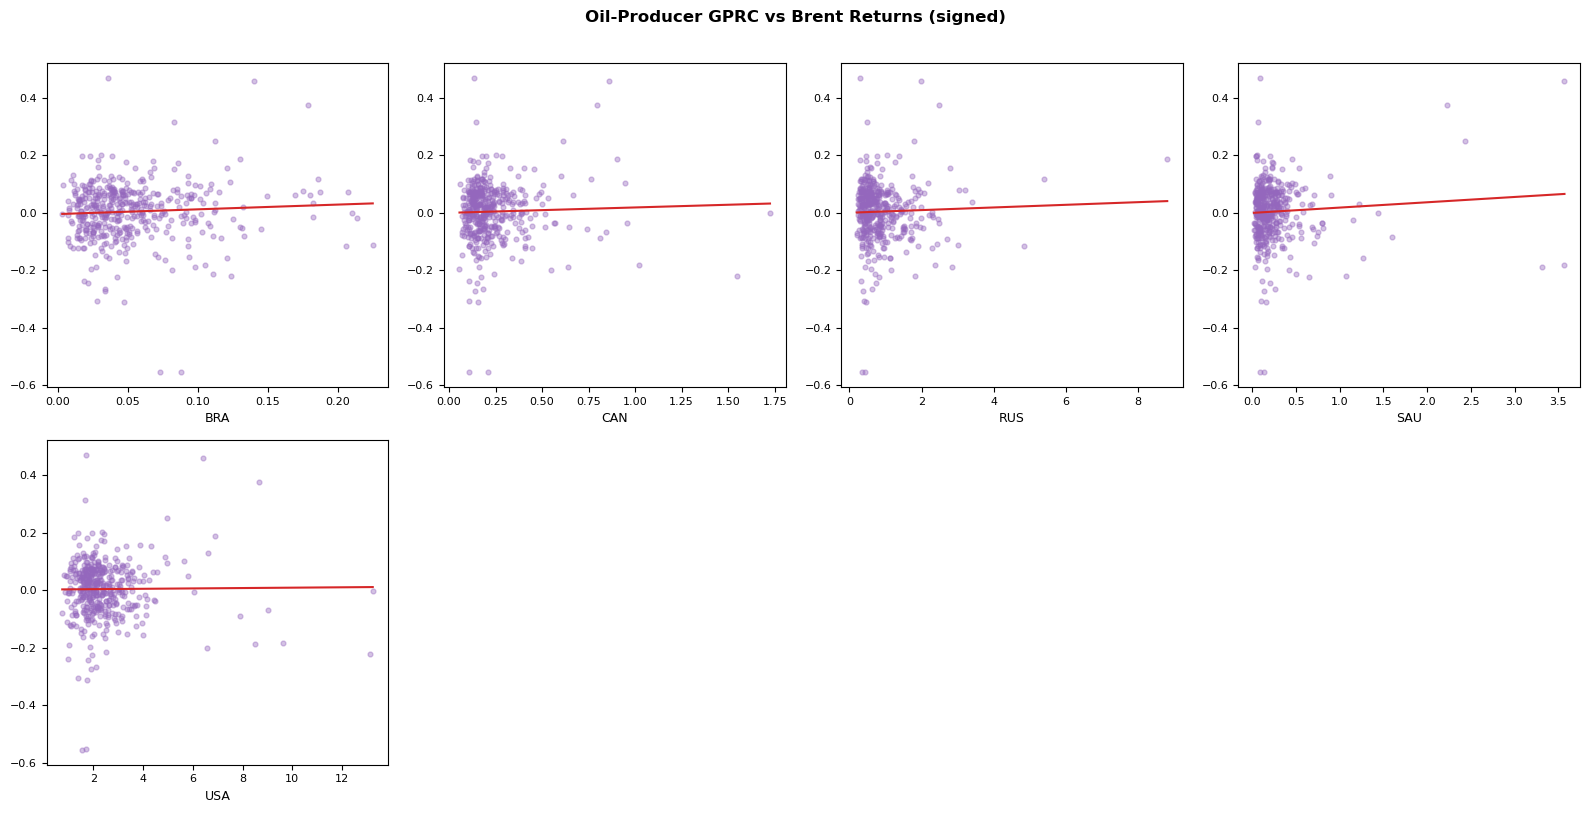

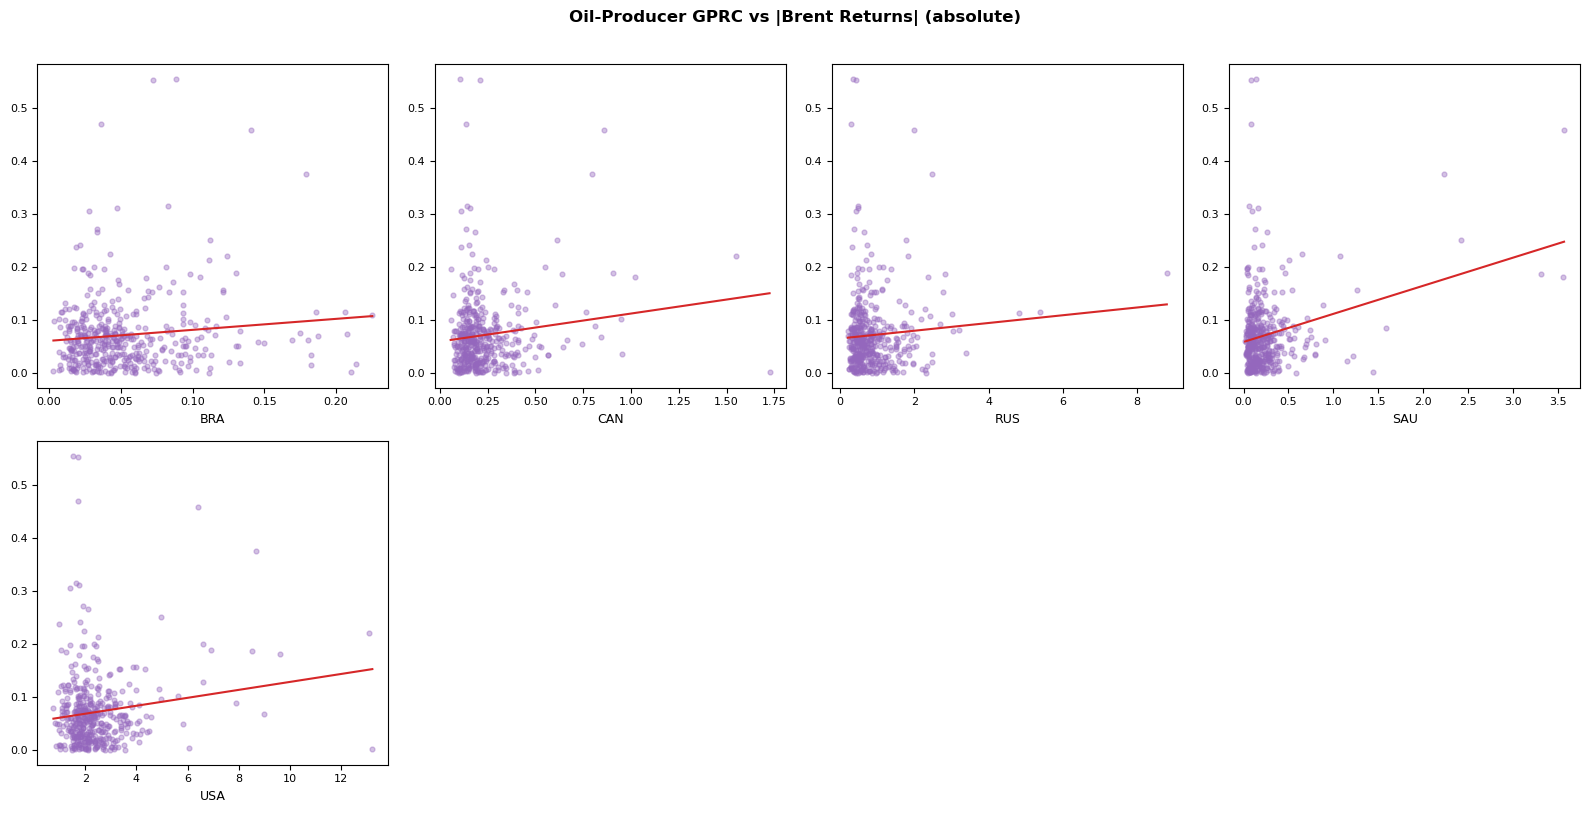

In [19]:
scatter_grid(monthly, exp_gprc, "Brent_Return",
             "Oil-Producer GPRC vs Brent Returns (signed)")
scatter_grid(monthly, exp_gprc, "Brent_Return",
             "Oil-Producer GPRC vs |Brent Returns| (absolute)", abs_y=True)

---
## 4. Monthly: Europe_Factor x Brent Returns

`Europe_Factor` is the first principal component of the EU country GPRC panel
(log-standardised), computed by `update_gpr()` in `data.py`. PCA scores can be
negative, so the column is **not** re-logged anywhere.


### 4.1 Time series: Europe_Factor vs Brent Returns

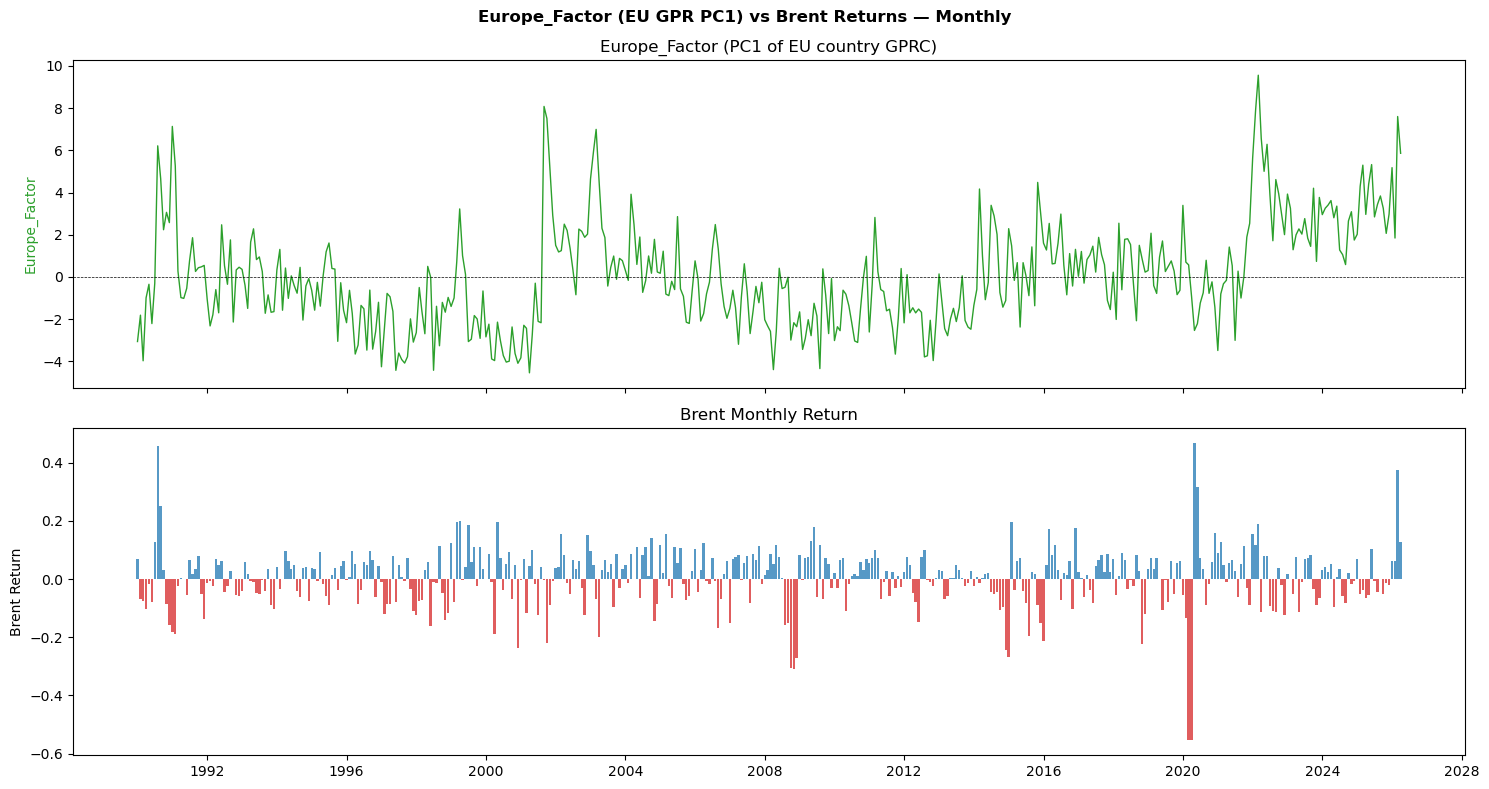

In [20]:
# Europe_Factor is the PCA first component of EU country GPR panel
pc = "Europe_Factor"

if pc not in monthly.columns:
    print(f"Column '{pc}' not found. Run update_gpr() to refresh gpr.xlsx.")
else:
    sub = monthly[[pc, "Brent_Return"]].dropna()

    fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
    fig.suptitle("Europe_Factor (EU GPR PC1) vs Brent Returns — Monthly", fontweight="bold")

    axes[0].plot(sub.index, sub[pc], color="tab:green", lw=1.0)
    axes[0].axhline(0, color="black", lw=0.5, ls="--")
    axes[0].set_ylabel("Europe_Factor", color="tab:green")
    axes[0].set_title("Europe_Factor (PC1 of EU country GPRC)")

    axes[1].bar(sub.index, sub["Brent_Return"],
                color=["tab:red" if v < 0 else "tab:blue" for v in sub["Brent_Return"]],
                width=25, alpha=0.75)
    axes[1].set_ylabel("Brent Return")
    axes[1].set_title("Brent Monthly Return")
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.tight_layout(); plt.show()

### 4.2 Europe_Factor vs Global GPR — how different are they?

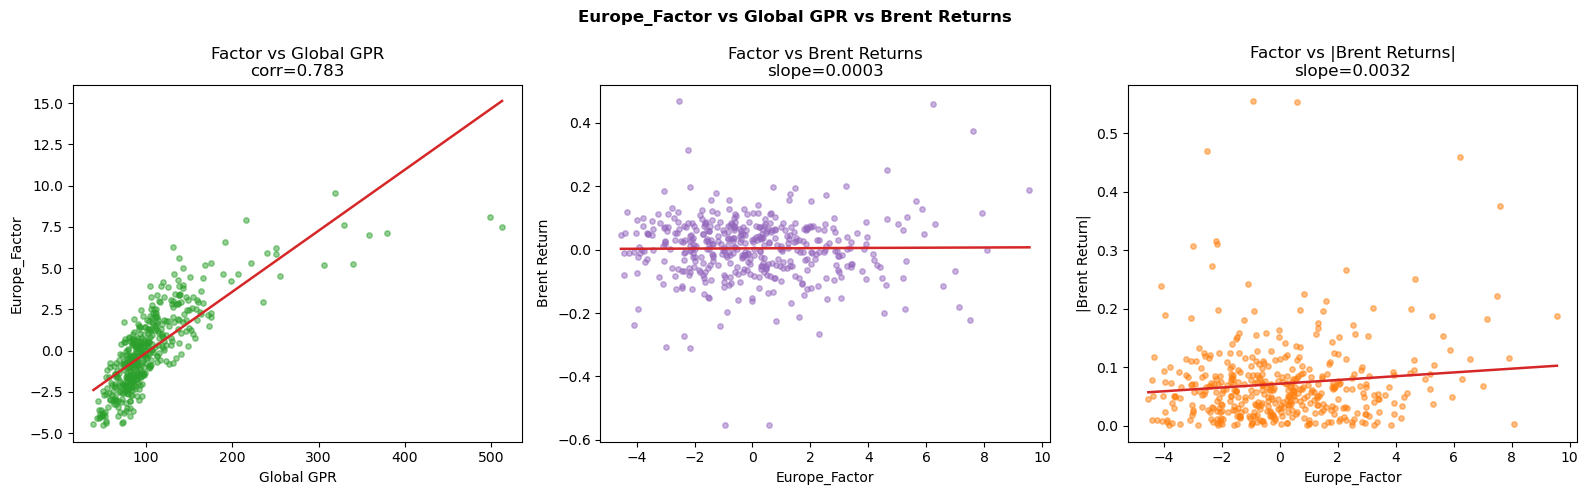

In [21]:
if pc in monthly.columns:
    sub = monthly[[pc, "GPR", "Brent_Return"]].dropna()

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Europe_Factor vs Global GPR vs Brent Returns", fontweight="bold")

    # Factor vs Global GPR
    axes[0].scatter(sub["GPR"], sub[pc], alpha=0.5, s=15, color="tab:green")
    m, b = np.polyfit(sub["GPR"], sub[pc], 1)
    xl = np.linspace(sub["GPR"].min(), sub["GPR"].max(), 200)
    axes[0].plot(xl, m * xl + b, color="tab:red", lw=1.8)
    axes[0].set_xlabel("Global GPR"); axes[0].set_ylabel("Europe_Factor")
    axes[0].set_title(f"Factor vs Global GPR\ncorr={sub['GPR'].corr(sub[pc]):.3f}")

    # Factor vs Brent signed
    axes[1].scatter(sub[pc], sub["Brent_Return"], alpha=0.5, s=15, color="tab:purple")
    m2, b2 = np.polyfit(sub[pc], sub["Brent_Return"], 1)
    xl2 = np.linspace(sub[pc].min(), sub[pc].max(), 200)
    axes[1].plot(xl2, m2 * xl2 + b2, color="tab:red", lw=1.8)
    axes[1].set_xlabel("Europe_Factor"); axes[1].set_ylabel("Brent Return")
    axes[1].set_title(f"Factor vs Brent Returns\nslope={m2:.4f}")

    # Factor vs |Brent|
    axes[2].scatter(sub[pc], sub["Brent_Return"].abs(), alpha=0.5, s=15, color="tab:orange")
    m3, b3 = np.polyfit(sub[pc], sub["Brent_Return"].abs(), 1)
    axes[2].plot(xl2, m3 * xl2 + b3, color="tab:red", lw=1.8)
    axes[2].set_xlabel("Europe_Factor"); axes[2].set_ylabel("|Brent Return|")
    axes[2].set_title(f"Factor vs |Brent Returns|\nslope={m3:.4f}")

    plt.tight_layout(); plt.show()

### 4.3 Distribution of Brent returns by Europe_Factor tercile

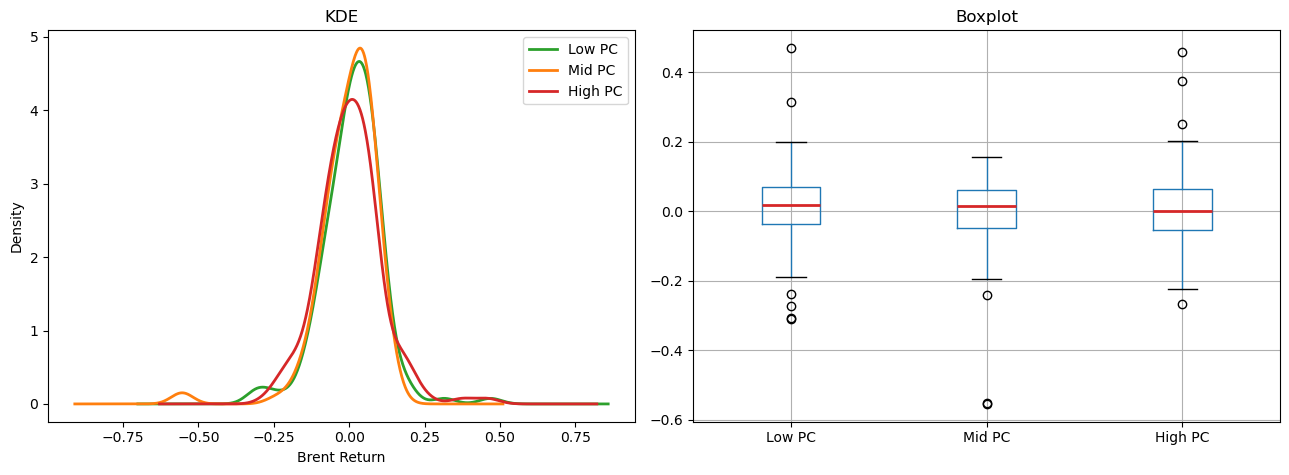

            count     mean      std      min      25%      50%      75%  \
PC_tercile                                                                
Low PC      145.0  0.01167  0.09877 -0.31094 -0.03713  0.01712  0.07076   
Mid PC      145.0 -0.00242  0.09824 -0.55491 -0.04926  0.01568  0.06041   
High PC     146.0  0.00298  0.10463 -0.26635 -0.05531 -0.00014  0.06274   

                max  
PC_tercile           
Low PC      0.46910  
Mid PC      0.15510  
High PC     0.45891  


C:\Users\Alejandro\AppData\Local\Temp\ipykernel_1760\1097479976.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(sub.groupby("PC_tercile")["Brent_Return"].describe().round(5))


In [22]:
if pc in monthly.columns:
    sub = monthly[[pc, "Brent_Return"]].dropna().copy()
    sub["PC_tercile"] = pd.qcut(sub[pc], q=3, labels=["Low PC", "Mid PC", "High PC"])

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Brent Return Distribution by Europe_Factor Tercile", fontweight="bold")

    for grp, color in zip(["Low PC", "Mid PC", "High PC"],
                           ["tab:green", "tab:orange", "tab:red"]):
        sub[sub["PC_tercile"] == grp]["Brent_Return"].plot.kde(
            ax=axes[0], label=grp, color=color, lw=2)
    axes[0].set_xlabel("Brent Return"); axes[0].set_title("KDE"); axes[0].legend()

    sub.boxplot(column="Brent_Return", by="PC_tercile", ax=axes[1],
                medianprops=dict(color="tab:red", lw=2))
    axes[1].set_title("Boxplot"); axes[1].set_xlabel(""); plt.suptitle("")
    plt.tight_layout(); plt.show()

    print(sub.groupby("PC_tercile")["Brent_Return"].describe().round(5))

### 4.4 Rolling 24-month correlation: Europe_Factor x Brent Returns

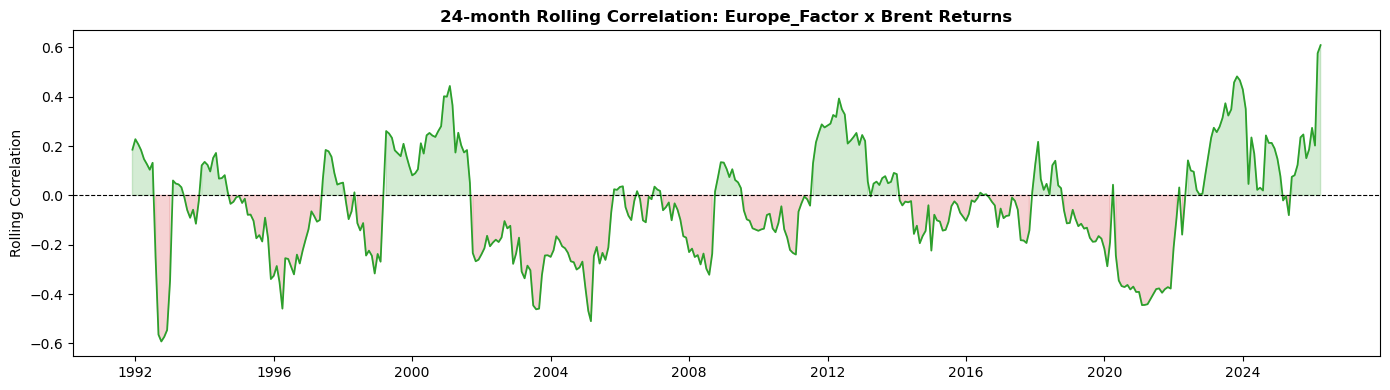

In [23]:
if pc in monthly.columns:
    sub = monthly[[pc, "Brent_Return"]].dropna()
    roll_pc = sub[pc].rolling(24).corr(sub["Brent_Return"])

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(roll_pc.index, roll_pc, color="tab:green", lw=1.3)
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.fill_between(roll_pc.index, roll_pc, 0, where=roll_pc >= 0, alpha=0.2, color="tab:green")
    ax.fill_between(roll_pc.index, roll_pc, 0, where=roll_pc <  0, alpha=0.2, color="tab:red")
    ax.set_ylabel("Rolling Correlation")
    ax.set_title("24-month Rolling Correlation: Europe_Factor x Brent Returns",
                 fontweight="bold")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.tight_layout(); plt.show()

---
## 5. Daily: Extended Controls x Brent Returns

For each control — VOIL, USD index, natural gas, crude stocks, REIA — the same
three-panel layout: (1) dual-axis time series, (2) scatter signed & absolute,
(3) 250-day rolling correlation.


In [24]:
def triple_plot(df, x_col, x_label, y_col="Brent_Return", window=250):
    sub = df[[x_col, y_col]].dropna()
    roll = sub[x_col].rolling(window).corr(sub[y_col])

    fig = plt.figure(figsize=(16, 11))
    gs  = fig.add_gridspec(3, 2, hspace=0.45, wspace=0.3)

    # Time series
    ax_ts = fig.add_subplot(gs[0, :])
    ax_ts.plot(sub.index, sub[y_col], color="tab:blue", lw=0.7, label="Brent Return")
    ax_ts.set_ylabel("Brent Return", color="tab:blue")
    ax2 = ax_ts.twinx()
    ax2.plot(sub.index, sub[x_col], color="tab:orange", alpha=0.65, lw=0.8, label=x_label)
    ax2.set_ylabel(x_label, color="tab:orange")
    ax_ts.set_title(f"{x_label} vs Brent Returns — Time Series")
    ax_ts.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    # Scatter signed
    ax_s = fig.add_subplot(gs[1, 0])
    ax_s.scatter(sub[x_col], sub[y_col], alpha=0.18, s=5, color="tab:purple", edgecolors="none")
    m, b = np.polyfit(sub[x_col], sub[y_col], 1)
    xl = np.linspace(sub[x_col].min(), sub[x_col].max(), 200)
    ax_s.plot(xl, m * xl + b, color="tab:red", lw=1.8)
    ax_s.set_xlabel(x_label); ax_s.set_ylabel("Brent Return")
    ax_s.set_title(f"Scatter — Signed Return   slope={m:.5f}")

    # Scatter absolute
    ax_a = fig.add_subplot(gs[1, 1])
    ax_a.scatter(sub[x_col], sub[y_col].abs(), alpha=0.18, s=5,
                 color="tab:orange", edgecolors="none")
    m2, b2 = np.polyfit(sub[x_col], sub[y_col].abs(), 1)
    ax_a.plot(xl, m2 * xl + b2, color="tab:red", lw=1.8)
    ax_a.set_xlabel(x_label); ax_a.set_ylabel("|Brent Return|")
    ax_a.set_title(f"Scatter — |Return|   slope={m2:.5f}")

    # Rolling correlation
    ax_r = fig.add_subplot(gs[2, :])
    ax_r.plot(roll.index, roll, color="tab:purple", lw=1.2)
    ax_r.axhline(0, color="black", lw=0.8, ls="--")
    ax_r.fill_between(roll.index, roll, 0, where=roll >= 0, alpha=0.2, color="tab:green")
    ax_r.fill_between(roll.index, roll, 0, where=roll <  0, alpha=0.2, color="tab:red")
    ax_r.set_ylabel("Rolling Corr")
    ax_r.set_title(f"{window}-day Rolling Correlation: {x_label} x Brent Returns")
    ax_r.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    fig.suptitle(f"{x_label} x Brent Returns", fontsize=13, fontweight="bold")
    plt.show()

    corr_s = sub[x_col].corr(sub[y_col])
    corr_a = sub[x_col].corr(sub[y_col].abs())
    print(f"  Full-sample corr  signed: {corr_s:+.4f}   absolute: {corr_a:+.4f}")

### 5.1 VOIL (oil volatility returns) x Brent Returns

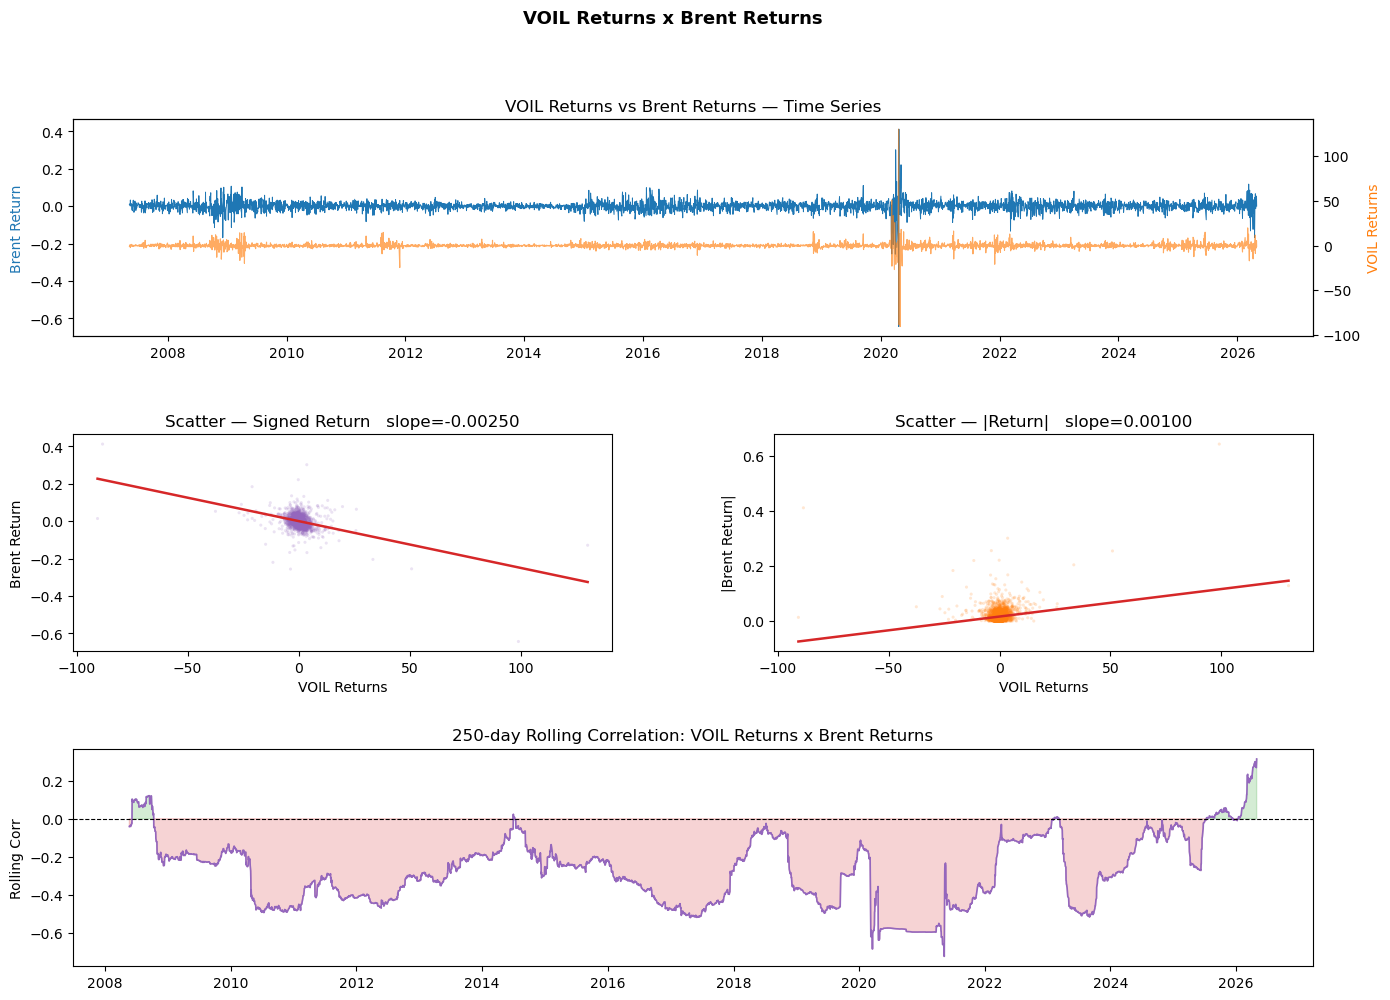

  Full-sample corr  signed: -0.3825   absolute: +0.1934


In [25]:
triple_plot(daily, "VOIL_Return", "VOIL Returns")

### 5.2 VOIL lag/lead structure — correlation profile

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (11,) and arg 1 with shape (9,).

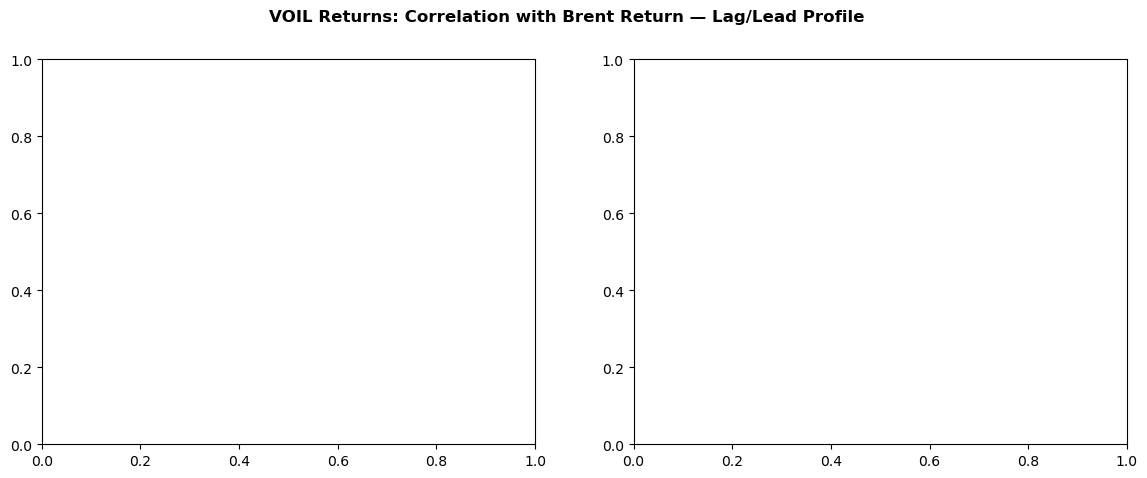

In [26]:
lag_lead_cols = (
    [f"VOIL_Return (t-{i})" for i in range(5, 0, -1)]
    + ["VOIL_Return"]
    + [c for c in voil_lead_cols if c in daily.columns]
)
lag_lead_cols = [c for c in lag_lead_cols if c in daily.columns]

corrs_s = [daily[c].corr(daily["Brent_Return"])      for c in lag_lead_cols]
corrs_a = [daily[c].corr(daily["Brent_Return"].abs()) for c in lag_lead_cols]

labels = (
    [f"t-{i}" for i in range(5, 0, -1)]
    + ["t"]
    + [c.replace("VOIL_Return ", "") for c in voil_lead_cols if c in daily.columns]
)
x_pos = np.arange(len(labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("VOIL Returns: Correlation with Brent Return — Lag/Lead Profile",
             fontweight="bold")

for ax, corrs, title in zip(axes,
                             [corrs_s, corrs_a],
                             ["vs Signed Brent Return", "vs |Brent Return|"]):
    ax.bar(x_pos, corrs, width=0.7,
           color=["tab:red" if v < 0 else "tab:blue" for v in corrs],
           edgecolor="white")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(x_pos); ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylabel("Pearson r"); ax.set_title(title)

plt.tight_layout(); plt.show()

### 5.3 USD index x Brent Returns

In [ ]:
triple_plot(daily, "usd_index",   "USD Index (level)")
triple_plot(daily, "usd_index_d", "USD Index (daily delta)")

### 5.4 Natural gas spot price x Brent Returns

In [ ]:
triple_plot(daily, "natgas_spotprice",   "Nat-Gas Spot (level)")
triple_plot(daily, "natgas_spotprice_d", "Nat-Gas Spot (daily delta)")

### 5.5 US weekly crude stocks x Brent Returns

In [ ]:
triple_plot(daily, "weekly_us_stocks",   "US Weekly Crude Stocks (level)")
triple_plot(daily, "weekly_us_stocks_d", "US Weekly Crude Stocks (delta)")

### 5.6 Real Economic Activity Index x Brent Returns

In [ ]:
triple_plot(daily, "REIA",    "REIA (level)")
triple_plot(daily, "REIA_ld", "REIA (log-diff)")

### 5.7 US Weekly Product Supplied x Brent Returns

*Weekly US product supplied* measures total petroleum products delivered to the
domestic market — a demand-side proxy for oil consumption. Weekly frequency,
forward-filled to daily. Both level and first-difference are examined.


In [ ]:
triple_plot(daily, "weekly_us_supply",   "US Weekly Product Supplied (level)")
triple_plot(daily, "weekly_us_supply_d", "US Weekly Product Supplied (delta)")

### 5.8 US Oil Production x Brent Returns

*US crude oil production* (thousand barrels/day) is a key supply-side driver of
global oil prices. Weekly/monthly frequency, forward-filled to daily.
Both level and first-difference are examined.


In [ ]:
triple_plot(daily, "us_oil_production",   "US Oil Production (level)")
triple_plot(daily, "us_oil_production_d", "US Oil Production (delta)")

---
## 6. Pairwise Overview & Correlation Matrices

Summary views across all candidate regressors and Brent returns at both frequencies.


### 6.1 Monthly correlation heatmap — sorted by strength

In [ ]:
monthly_corr_cols = [c for c in
    ["GPR", "Europe_Factor"] + eu_gprc + exp_gprc
    + ["Brent_Return"]
    if c in monthly.columns]

corr_m = monthly[monthly_corr_cols].corr()
sort_order = corr_m["Brent_Return"].abs().sort_values(ascending=False).index
corr_m_sorted = corr_m.loc[sort_order, sort_order]

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_m_sorted, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.3, ax=ax, cbar_kws={"shrink": 0.7}, annot_kws={"size": 7})
ax.set_title("Monthly Correlation Matrix — Sorted by |corr with Brent_Return|",
             fontweight="bold")
plt.tight_layout(); plt.show()

### 6.2 Daily correlation heatmap — extended controls

In [ ]:
daily_corr_cols = [c for c in [
    "GPRD",
    "VOIL_Return", "VOIL_Return (t-1)", "VOIL_Return (t-2)",
    "usd_index_d", "natgas_spotprice_d",
    "weekly_us_stocks_d", "weekly_us_supply_d", "us_oil_production_d",
    "REIA_ld",
    "Brent_Return", "Realized_Volatility"
] if c in daily.columns]

corr_d = daily[daily_corr_cols].corr()
sort_d = corr_d["Brent_Return"].abs().sort_values(ascending=False).index
corr_d_sorted = corr_d.loc[sort_d, sort_d]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_d_sorted, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.3, ax=ax, cbar_kws={"shrink": 0.7}, annot_kws={"size": 8})
ax.set_title("Daily Correlation Matrix — Sorted by |corr with Brent_Return|",
             fontweight="bold")
plt.tight_layout(); plt.show()

### 6.3 Monthly pairplot — GPR variables vs Brent

In [ ]:
pair_cols_m = [c for c in ["GPR", "Europe_Factor", "Brent_Return"]
               if c in monthly.columns]

g = sns.pairplot(monthly[pair_cols_m].dropna(),
                 plot_kws={"alpha": 0.4, "s": 10}, diag_kind="kde", corner=True)
g.figure.suptitle("Monthly Pairplot — GPR, Europe_Factor, Brent_Return",
                   y=1.01, fontweight="bold")
plt.show()

### 6.4 Daily pairplot — extended controls vs Brent

In [ ]:
pair_cols_d = [c for c in [
    "GPRD", "VOIL_Return", "usd_index_d",
    "natgas_spotprice_d", "weekly_us_supply_d", "us_oil_production_d",
    "Brent_Return"
] if c in daily.columns]

g = sns.pairplot(
    daily[pair_cols_d].dropna().sample(min(3000, len(daily)), random_state=42),
    plot_kws={"alpha": 0.2, "s": 4}, diag_kind="kde", corner=True)
g.figure.suptitle("Daily Pairplot — GPRD, Controls, Brent_Return (sample n=3,000)",
                   y=1.01, fontweight="bold")
plt.show()

### 6.5 Correlation bar chart — all variables ranked vs Brent Returns

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle("All Variables: Pearson Correlation with Brent_Return",
             fontsize=13, fontweight="bold")

for ax, df, title, exclude in [
    (axes[0], monthly, "Monthly", ["Brent_Return"]),
    (axes[1], daily,   "Daily",   ["Brent_Return", "Realized_Volatility"]),
]:
    num_cols = df.select_dtypes(include=[np.number]).columns
    candidates = [c for c in num_cols if c not in exclude]
    corrs = (df[candidates + ["Brent_Return"]]
             .corr()["Brent_Return"]
             .drop("Brent_Return")
             .dropna()
             .sort_values())
    colors = ["tab:red" if v < 0 else "tab:blue" for v in corrs]
    ax.barh(corrs.index, corrs.values, color=colors, edgecolor="white")
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("Pearson r"); ax.set_title(title)
    ax.tick_params(axis="y", labelsize=8)

plt.tight_layout(); plt.show()